In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
import torch

X shape: (2000, 2)
First 5 X:
 [[ 1.7765071   0.19275202]
 [ 0.39780872  0.93039011]
 [ 0.49530794 -0.31832132]
 [-0.94894379  0.16301974]
 [ 0.48495693 -0.33816023]]
Mean of X: [0.49921708 0.2507061 ]
Std of X: [0.87202523 0.50447609]


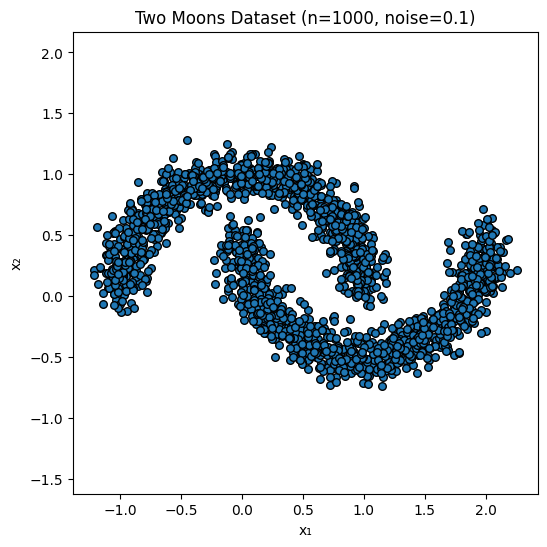

In [7]:
#  Generate data
X, _ = make_moons(n_samples=2000, noise=0.1, random_state=42)
# Inspect shapes and first few rows
print("X shape:", X.shape)    
print("First 5 X:\n", X[:5])
print("Mean of X:", X.mean(axis=0))
print("Std of X:", X.std(axis=0))


plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], edgecolor='k', s=30)
plt.title("Two Moons Dataset (n=1000, noise=0.1)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.axis("equal")
plt.show()

## Sanity Check: 
Identity of forward and inverse pass is established:

In [8]:
from affine_coupling import AffineCoupling
from affine_coupling import NormalizingFlow

with torch.no_grad():
    ac = AffineCoupling(size=2, d=1, hidden_size=64) 
    ac.test_identity(tolerance=1e-6)

    nf = NormalizingFlow(input_dim=2, num_layers=4, hidden_size=64)
    nf.test_identity(tolerance=1e-6)

Min: 0.0, Max: 2.9802322387695312e-08
Min: -1.4901161193847656e-07, Max: 0.0


## Training the Normalizing Flow
Batch Size: 64
Learning Rate: 0.001
Epochs: 100
Optimizer: AdamW
- $\beta_1$: 0.9
- $\beta_2$: 0.999
- Weight decay: 0.01

To get a better understanding of the model's reconstructive capabilities, we calculate the directed Hausdorff-Distance (Taha and Hanbury, 2015) between the generated samples and the original point-cloud. To better understand the performance, we center the reconstruction to standard deviation and mean of original distribution.

Config file not found: config.yaml
Epoch 1, Loss: 158.0732
Hausdorff distance: 0.9660
Epoch 2, Loss: 157.4659
Hausdorff distance: 1.2942
Epoch 3, Loss: 177.6027
Hausdorff distance: 1.3385
Epoch 4, Loss: 147.6227
Hausdorff distance: 0.8139
Epoch 5, Loss: 142.8547
Hausdorff distance: 1.3460
Epoch 6, Loss: 144.0755
Hausdorff distance: 1.9171
Epoch 7, Loss: 139.3820
Hausdorff distance: 1.2034
Epoch 8, Loss: 129.9228
Hausdorff distance: 0.8364
Epoch 9, Loss: 123.4151
Hausdorff distance: 1.4773
Epoch 10, Loss: 149.0956
Hausdorff distance: 0.7323
Epoch 11, Loss: 118.7281
Hausdorff distance: 1.8456
Epoch 12, Loss: 120.8777
Hausdorff distance: 1.4825
Epoch 13, Loss: 121.5461
Hausdorff distance: 0.7353
Epoch 14, Loss: 118.5732
Hausdorff distance: 3.0622
Epoch 15, Loss: 116.2485
Hausdorff distance: 4.0110
Epoch 16, Loss: 115.8674
Hausdorff distance: 1.8471
Epoch 17, Loss: 116.8973
Hausdorff distance: 2.6525
Epoch 18, Loss: 103.4605
Hausdorff distance: 1.3841
Epoch 19, Loss: 119.0480
Hausdorff dis

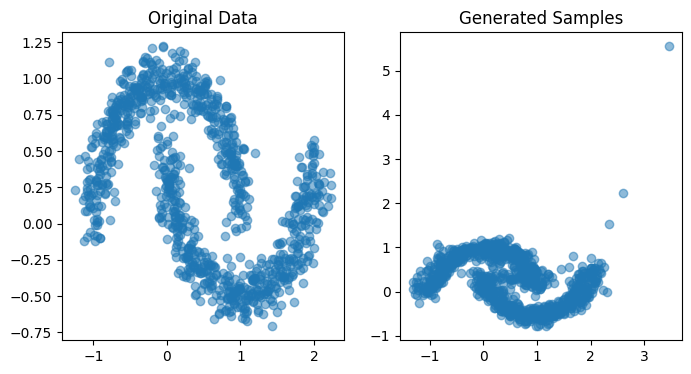

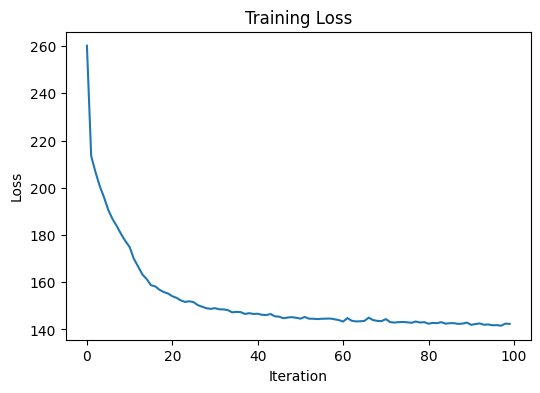

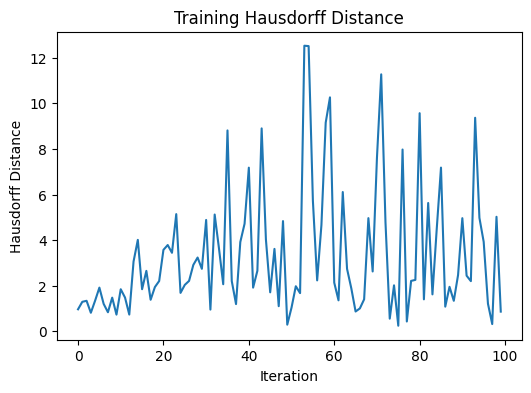

In [ ]:
import torch.utils.data as data
from affine_coupling import NormalizingFlow
from config import Config
from sklearn.datasets import make_moons
from train import train_loop

config = Config('config.yaml')

np.random.seed(6)
torch.manual_seed(6)


X, _ = make_moons(n_samples=config.samples, noise=0.1)
x_tensor = torch.tensor(X, dtype=torch.float32)
dataset = data.TensorDataset(x_tensor)
dataloader = data.DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


## Alternative Masks
The default masks the first dimension. Here, we switch the dimension, and leave the mask altogether. 

Epoch 1, Loss: 162.4442
Hausdorff distance: 1.4956
Epoch 2, Loss: 158.2313
Hausdorff distance: 1.7320
Epoch 3, Loss: 149.9356
Hausdorff distance: 1.2123
Epoch 4, Loss: 137.6945
Hausdorff distance: 1.3747
Epoch 5, Loss: 124.7126
Hausdorff distance: 0.9236
Epoch 6, Loss: 134.8580
Hausdorff distance: 1.2758
Epoch 7, Loss: 131.5032
Hausdorff distance: 1.2377
Epoch 8, Loss: 139.4254
Hausdorff distance: 0.7641
Epoch 9, Loss: 141.9667
Hausdorff distance: 0.8151
Epoch 10, Loss: 143.5044
Hausdorff distance: 0.7367
Epoch 11, Loss: 135.8900
Hausdorff distance: 1.4634
Epoch 12, Loss: 120.9713
Hausdorff distance: 0.7960
Epoch 13, Loss: 122.5933
Hausdorff distance: 0.7595
Epoch 14, Loss: 124.8498
Hausdorff distance: 0.7203
Epoch 15, Loss: 135.2013
Hausdorff distance: 0.8991
Epoch 16, Loss: 123.3873
Hausdorff distance: 0.4887
Epoch 17, Loss: 117.5584
Hausdorff distance: 1.0956
Epoch 18, Loss: 122.9659
Hausdorff distance: 0.3774
Epoch 19, Loss: 136.9240
Hausdorff distance: 0.8217
Epoch 20, Loss: 114.7

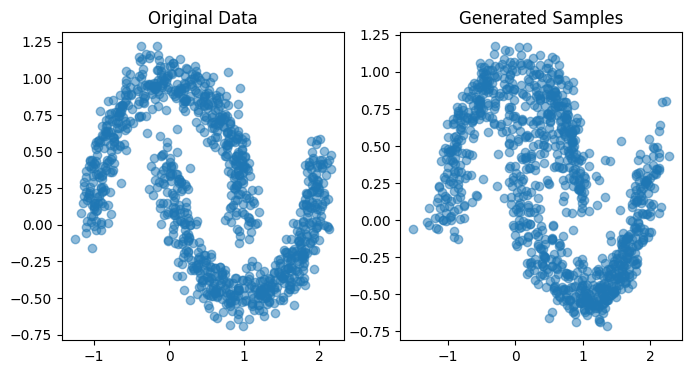

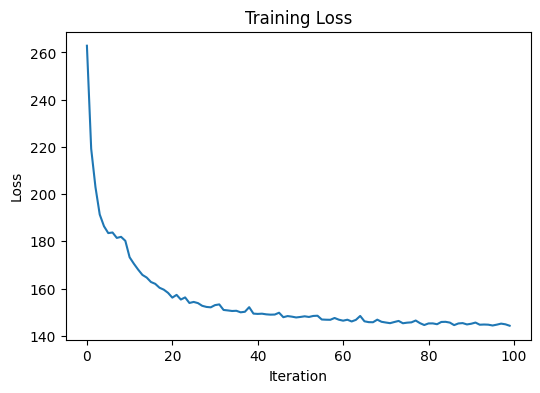

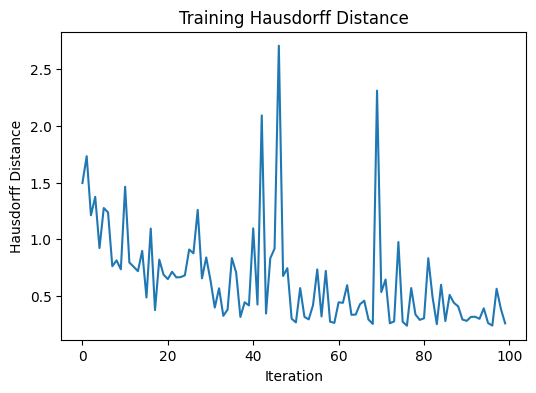

In [ ]:
mask = torch.zeros(2)
mask[0] = 1.

np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


No mask:

/Volumes/KG1TB/Developement/M4ML-2025-Normalizing-Flows/.venv/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Epoch 1, Loss: 234.4064
Hausdorff distance: 1.3585
Epoch 2, Loss: 236.4793
Hausdorff distance: 1.5873
Epoch 3, Loss: 247.0012
Hausdorff distance: 1.2606
Epoch 4, Loss: 238.5568
Hausdorff distance: 1.5959
Epoch 5, Loss: 234.7442
Hausdorff distance: 1.3959
Epoch 6, Loss: 247.4948
Hausdorff distance: 1.4531
Epoch 7, Loss: 234.3937
Hausdorff distance: 1.2303
Epoch 8, Loss: 252.7954
Hausdorff distance: 1.2782
Epoch 9, Loss: 240.3461
Hausdorff distance: 1.2188
Epoch 10, Loss: 237.2505
Hausdorff distance: 1.6379
Epoch 11, Loss: 251.9960
Hausdorff distance: 1.2115
Epoch 12, Loss: 238.7516
Hausdorff distance: 1.3933
Epoch 13, Loss: 238.0471
Hausdorff distance: 1.1220
Epoch 14, Loss: 240.9493
Hausdorff distance: 1.4527
Epoch 15, Loss: 244.3970
Hausdorff distance: 1.3808
Epoch 16, Loss: 233.8242
Hausdorff distance: 1.3360
Epoch 17, Loss: 233.7943
Hausdorff distance: 2.0519
Epoch 18, Loss: 241.6849
Hausdorff distance: 1.9295
Epoch 19, Loss: 248.3285
Hausdorff distance: 1.4148
Epoch 20, Loss: 242.6

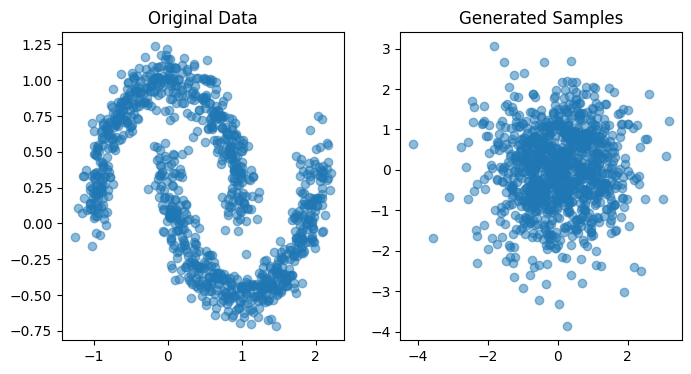

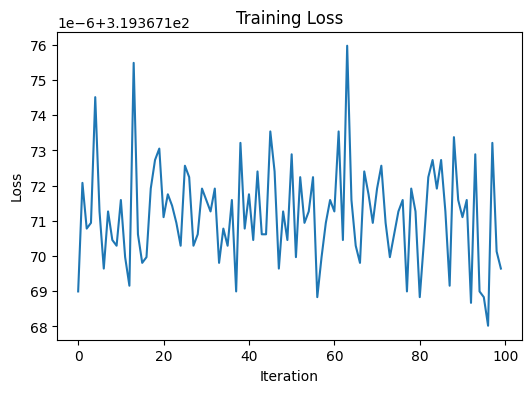

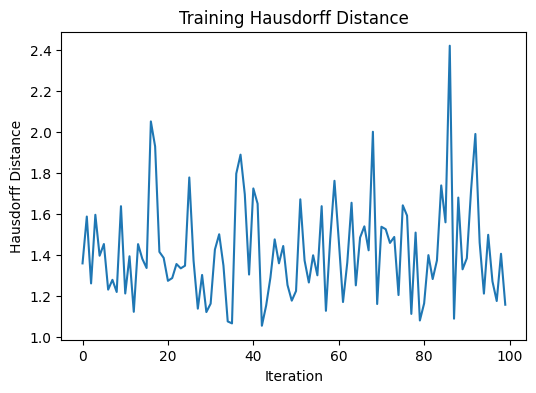

In [ ]:
mask = torch.ones(2)

np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


All mask:

Epoch 1, Loss: 215.5650
Hausdorff distance: 1.3998
Epoch 2, Loss: 197.8751
Hausdorff distance: 1.1867
Epoch 3, Loss: 190.5202
Hausdorff distance: 1.0570
Epoch 4, Loss: 200.8402
Hausdorff distance: 1.3657
Epoch 5, Loss: 191.0874
Hausdorff distance: 1.2720
Epoch 6, Loss: 193.7016
Hausdorff distance: 1.1324
Epoch 7, Loss: 185.4531
Hausdorff distance: 1.2172
Epoch 8, Loss: 194.4329
Hausdorff distance: 1.4544
Epoch 9, Loss: 189.0106
Hausdorff distance: 1.5062
Epoch 10, Loss: 193.0771
Hausdorff distance: 1.9022
Epoch 11, Loss: 188.9496
Hausdorff distance: 1.4142
Epoch 12, Loss: 191.4037
Hausdorff distance: 1.6266
Epoch 13, Loss: 197.6884
Hausdorff distance: 1.3050
Epoch 14, Loss: 193.4012
Hausdorff distance: 1.2386
Epoch 15, Loss: 192.3334
Hausdorff distance: 1.2855
Epoch 16, Loss: 187.1666
Hausdorff distance: 1.1409
Epoch 17, Loss: 200.4690
Hausdorff distance: 1.2510
Epoch 18, Loss: 197.1378
Hausdorff distance: 1.3410
Epoch 19, Loss: 201.9935
Hausdorff distance: 1.2875
Epoch 20, Loss: 203.6

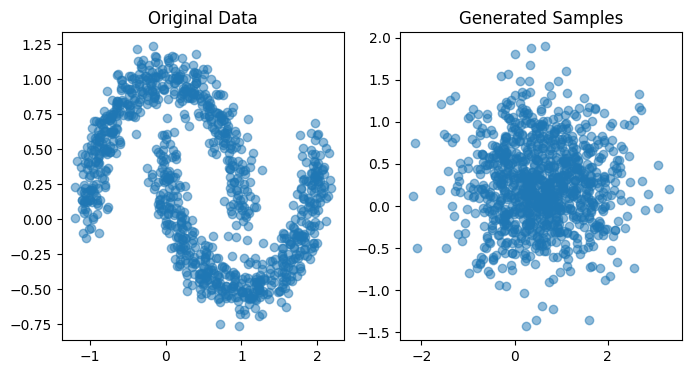

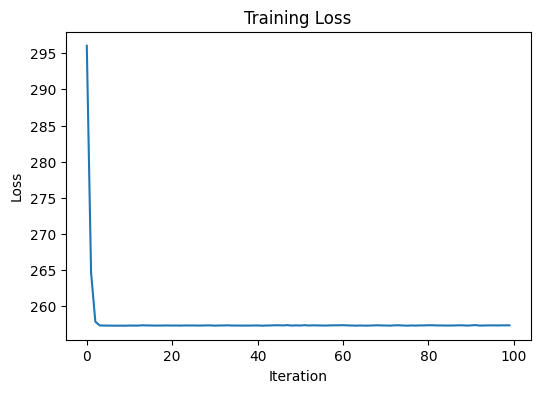

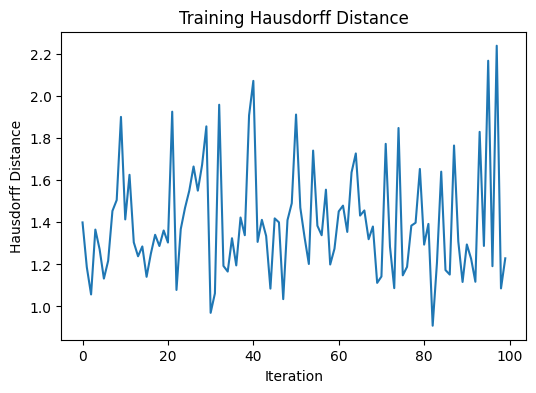

In [ ]:
mask = torch.zeros(2)
np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()
